In [3]:
import pandas as pd
df=pd.read_csv("/Users/venkatakrishnavanaparthi/Desktop/country_stats_app/source_data/Country_data.csv")

In [4]:
df.head(5)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [5]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 14.5 KB


In [7]:
#df['segment'].value_counts()

In [8]:
#Check for missing values and duplicates.

#df.isnull()
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [9]:
#duplicates checking
d=df['country'].duplicated().sum()
print(d)

0


In [10]:
print("Total duplicates:", df.duplicated().sum())
print("Duplicate countries:", df['country'].duplicated().sum())

Total duplicates: 0
Duplicate countries: 0


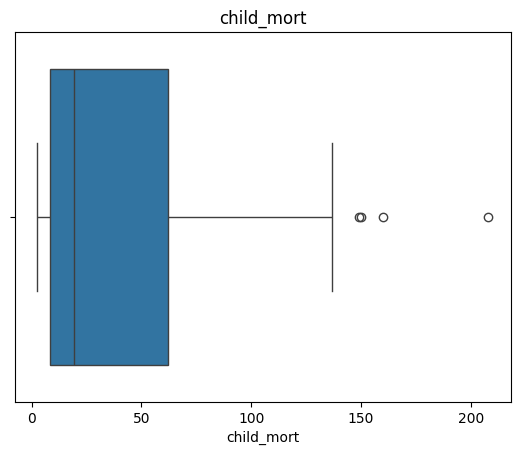

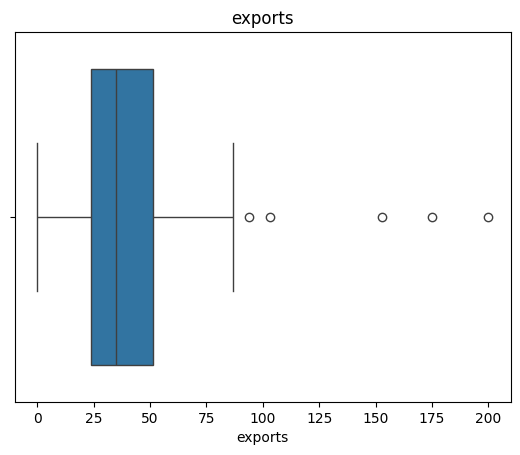

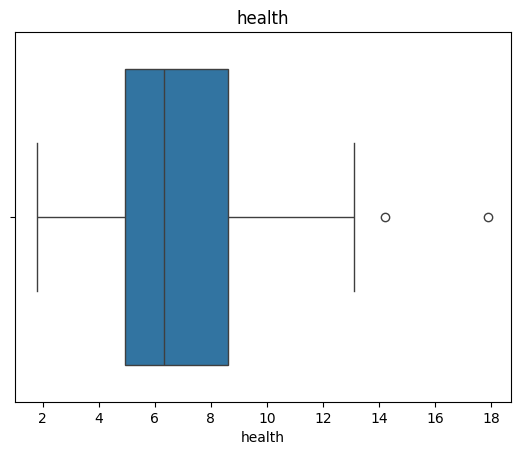

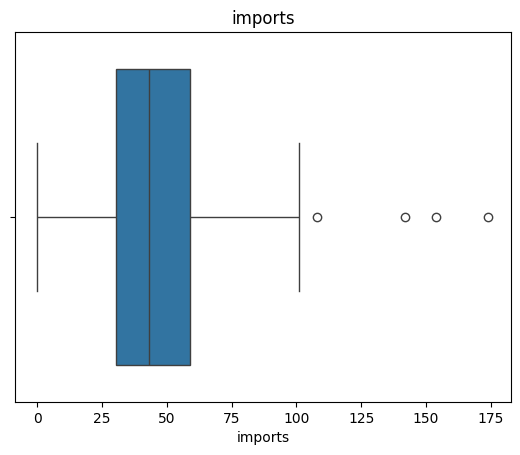

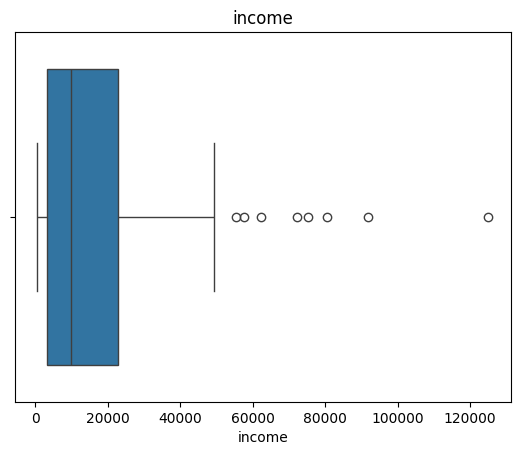

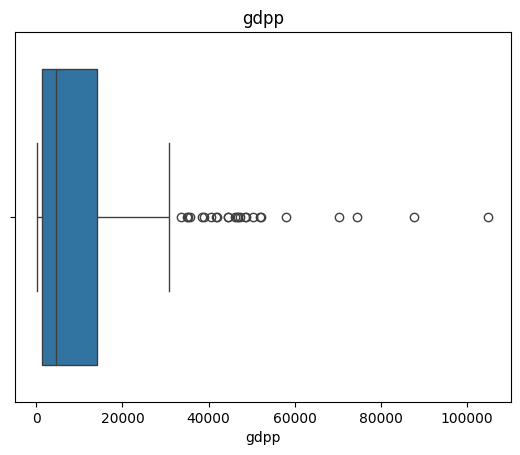

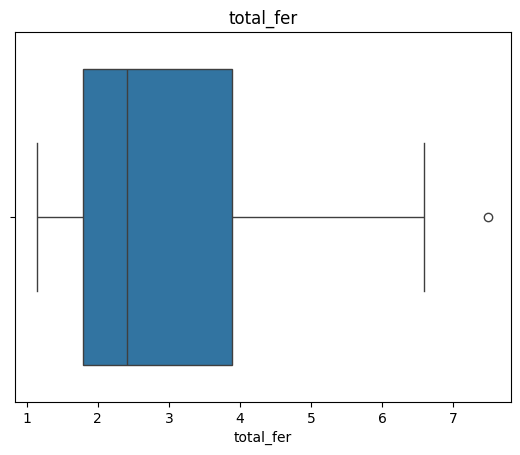

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
cols = ['child_mort','exports','health','imports','income','gdpp','total_fer']

for col in cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [12]:
#outliers code
cols = ['income', 'gdpp', 'child_mort', 'inflation']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"{col}: {len(outliers)} outliers")

income: 8 outliers
gdpp: 25 outliers
child_mort: 4 outliers
inflation: 5 outliers


In [13]:
#skew
df[['income','gdpp','child_mort','inflation']].skew()
#Skewness value	Meaning	Action
#-1 to +1	Already good	✅ Do nothing
#> +1	Highly right skewed	🔄 Apply log
#< -1	Highly left skewed	🔄 Consider transform (rare)'''
#income        2.231480,
#gdpp          2.218051
#child_mort    1.450774
#inflation     5.154049

income        2.231480
gdpp          2.218051
child_mort    1.450774
inflation     5.154049
dtype: float64

In [14]:
#1. income, Skew: normal,Outliers: very few,Action: Do nothing
#if we do anything to income data will loose its originality,so do nothing


In [15]:
#2. gdpp, Skew: normal,Outliers: 25 (check %!)

#####-----> Do NOT use log (no skew problem)



#*************iam preferring log bcoz capping will delete the rows but gdp is important
#GDPP	Very rich countries	Transform (log), sometimes cap
#Child mortality---->Very poor health systems	Keep, or log-transform

In [16]:
#2
import numpy as np
df['income']=np.log1p(df['income'])
df['gdpp'] = np.log1p(df['gdpp'])

In [17]:
#3. child_mort,Skewness = 1.45 → moderately right-skewed,Outliers ≈ 2.4% → low
#For child_mort, do NOT remove outliers by default, Prefer:1.Keep as-is for analysis,2.Log transform or robust scaling for ML
# Action: Only LOG transform
#**********Child mortality---beforelog


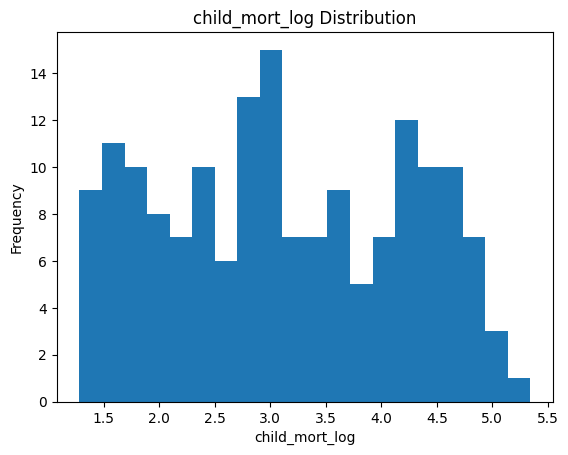

In [18]:
#3
import numpy as np

df['child_mort'] = np.log1p(df['child_mort'])

plt.hist(df['child_mort'], bins=20)
plt.title("child_mort_log Distribution")
plt.xlabel("child_mort_log")
plt.ylabel("Frequency")
plt.show()

In [19]:
mean_inflation = df['inflation'].mean()
median_inflation = df['inflation'].median()

print("Mean inflation:", mean_inflation)
print("Median inflation:", median_inflation)
Q1 = df['inflation'].quantile(0.25)
Q3 = df['inflation'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print("IQR is:",IQR)
outliers = df.loc[
    (df['inflation'] < lower) | (df['inflation'] > upper),
    ['country', 'inflation']
]

print(outliers)

Mean inflation: 7.781832335329342
Median inflation: 5.39
IQR is: 8.94
               country  inflation
49   Equatorial Guinea       24.9
103           Mongolia       39.2
113            Nigeria      104.0
149        Timor-Leste       26.5
163          Venezuela       45.9


In [20]:
cols = ['income', 'gdpp', 'child_mort', 'inflation']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"{col}: {len(outliers)} outliers")

income: 0 outliers
gdpp: 0 outliers
child_mort: 0 outliers
inflation: 5 outliers


In [21]:
cols = ['income', 'gdpp', 'child_mort', 'inflation']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

income: 0 outliers
gdpp: 0 outliers
child_mort: 0 outliers
inflation: 5 outliers


In [22]:
#Validate data types for all numeric columns.
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(numeric_cols)

Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp'],
      dtype='str')


In [23]:
for col in numeric_cols:
    negatives = df[df[col] < 0]
    if not negatives.empty:
        print(f"Negative values in {col}:")
        print(negatives[[col]])

Negative values in inflation:
     inflation
10      -0.393
43      -1.430
73      -3.220
77      -1.900
85      -0.812
131     -4.210
133     -0.046
135     -0.987


In [24]:
#4. inflation
#Skewness = 5.15 → extremely skewed,Outliers ≈ 3% → moderate,Action: LOG + CAPPING
#Case A — You are doing clustering / ML / segmentation
#Then outliers can distort distance and scaling.
#Best options:
#✅ Option 1: Log transformation (most common)
#Since inflation is skewed:,But ⚠️ inflation has negatives → direct log won’t work.
#**********Apply: log1p(inflation) (handles zeros & negatives carefully using shift if needed)
#So instead:

#log can not be applied on negative values

In [25]:
#so
df['inflation_log'] = np.log1p(df['inflation'] - df['inflation'].min() + 1)

In [26]:
for col in numeric_cols:
    negatives = df[df[col] < 0]
    if not negatives.empty:
        print(f"Negative values in {col}:")
        print(negatives[[col]])

Negative values in inflation:
     inflation
10      -0.393
43      -1.430
73      -3.220
77      -1.900
85      -0.812
131     -4.210
133     -0.046
135     -0.987


In [27]:
#Handle negative or extreme inflation values.

Q1 = df['inflation'].quantile(0.25)
Q3 = df['inflation'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
extreme = df[(df['inflation'] < lower) | (df['inflation'] > upper)]
print(extreme)

               country  child_mort  exports  health  imports     income  \
49   Equatorial Guinea    4.718499     85.8    4.48     58.9  10.425283   
103           Mongolia    3.299534     46.7    5.44     56.7   8.950403   
113            Nigeria    4.875197     25.3    5.07     17.4   8.546946   
149        Timor-Leste    4.152613      2.2    9.12     27.8   7.523481   
163          Venezuela    2.895912     28.5    4.91     17.6   9.711176   

     inflation  life_expec  total_fer      gdpp  inflation_log  
49        24.9        60.9       5.21  9.746892       3.437529  
103       39.2        66.2       2.64  7.882692       3.815732  
113      104.0        60.5       5.84  7.754053       4.702388  
149       26.5        71.1       6.23  8.188967       3.487681  
163       45.9        75.4       2.47  9.510519       3.953357  


In [28]:
df[['income','gdpp','child_mort','inflation']].skew()
#Skewness value	Meaning	Action

income       -0.235823
gdpp          0.006548
child_mort    0.066160
inflation     5.154049
dtype: float64

In [29]:
print(extreme[['country', 'inflation']])

               country  inflation
49   Equatorial Guinea       24.9
103           Mongolia       39.2
113            Nigeria      104.0
149        Timor-Leste       26.5
163          Venezuela       45.9


In [30]:
#Column	Expected Rule
#child_mort	≥ 0,exports	≥ 0 (usually % of GDP),#total_fer	> 0 (typically 1–8)
#health	≥ 0,imports	≥ 0,income	> 0,,gdpp	> 0

#country	Unique, no extra spaces

#inflation	Can be negative (OK)
#life_expec	30–100 (realistic range)


In [31]:
#Perform consistency checks.
#Consistency checks are about:“Does this data make real-world sense?”

#Not:Skewness,Outliers
# strip spaces
df['country'] = df['country'].str.strip()

# duplicates
df['country'].duplicated().sum()

np.int64(0)

In [32]:
# Negative values where NOT allowed
cols = ['child_mort','exports','health','imports','income','gdpp','total_fer']

for col in cols:
    print(col, df[df[col] < 0].shape[0])

child_mort 0
exports 0
health 0
imports 0
income 0
gdpp 0
total_fer 0


In [33]:
# Valid conditions
valid_life = (df['life_expec'] < 30) & (df['life_expec'] >100)
valid_fer = (df['total_fer'] <= 0) & (df['total_fer'] >10)

In [34]:
logical_check = df[(df['child_mort'] > 100) & (df['life_expec'] > 80)]
print(f"Potential Logical Anomalies: {len(logical_check)}")

Potential Logical Anomalies: 0


In [35]:
for col in numeric_cols:
    negatives = df[df[col] < 0]
    if not negatives.empty:
        print(f"Negative values in {col}:")
        print(negatives[[col]])

Negative values in inflation:
     inflation
10      -0.393
43      -1.430
73      -3.220
77      -1.900
85      -0.812
131     -4.210
133     -0.046
135     -0.987


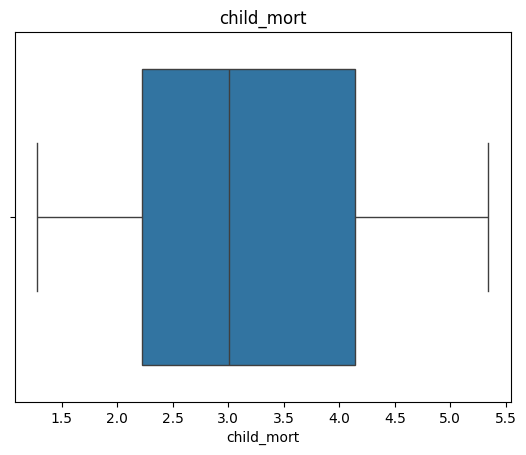

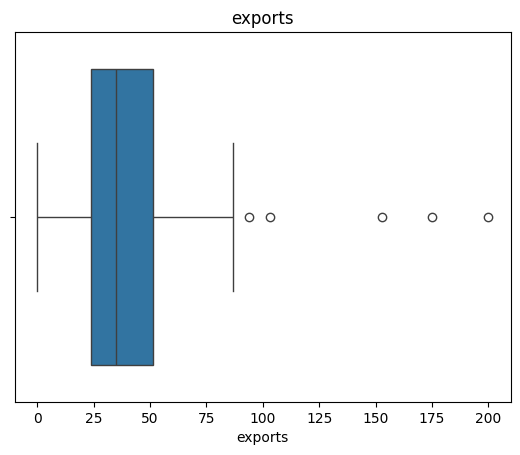

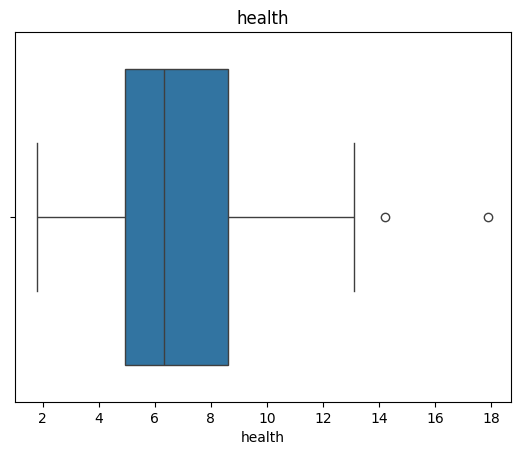

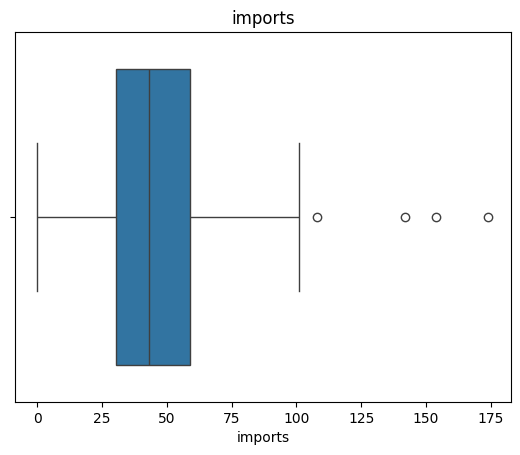

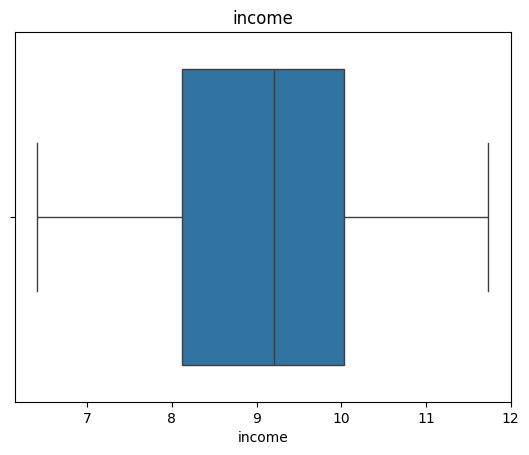

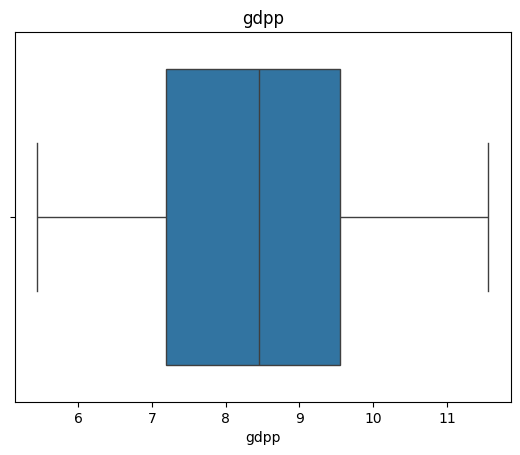

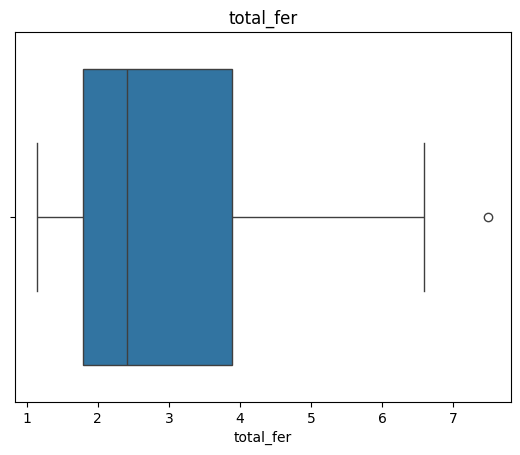

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [37]:
df.head(5)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,inflation_log
0,Afghanistan,4.513055,10.0,7.58,44.9,7.384610,9.44,56.2,5.82,6.317165,2.750471
1,Albania,2.867899,28.0,6.55,48.6,9.203416,4.49,76.3,1.65,8.316545,2.370244
2,Algeria,3.342862,38.4,4.17,31.4,9.465060,16.10,76.5,2.89,8.403128,3.105035
3,Angola,4.787492,62.3,2.85,42.9,8.682877,22.40,60.1,6.16,8.169336,3.353756
4,Antigua and Barbuda,2.424803,45.5,6.03,58.9,9.857496,1.44,76.8,2.13,9.409273,2.034706


In [38]:
#df['Development_Index'] = ( df['income'] + df['gdpp'] + df['life_expec']) / (df['child_mort'])
#print(df[['country','Development_Index']])
#formula has a major issue: scale mismatch
#income, gdpp → very large numbers (thousands)
#life_expec → small (~50–80)
#child_mort → smaller (~1–100)

#👉 This means:

#GDP & income dominate the index
#life expectancy has almost no impact
#result is biased, not balanced

In [39]:
from sklearn.preprocessing import MinMaxScaler

cols = ['income','gdpp','life_expec','child_mort']

scaled = MinMaxScaler().fit_transform(df[cols])
df_scaled = pd.DataFrame(scaled, columns=cols)

df['development_index'] = (
    df_scaled['income'] +
    df_scaled['gdpp'] +
    df_scaled['life_expec']
) / (df_scaled['child_mort'] + 1e-6)

In [40]:
print(df[['country','development_index']])

                 country  development_index
0            Afghanistan           1.005442
1                Albania           4.773639
2                Algeria           3.806523
3                 Angola           1.649172
4    Antigua and Barbuda           7.728587
..                   ...                ...
162              Vanuatu           2.525619
163            Venezuela           5.377130
164              Vietnam           3.120064
165                Yemen           1.990196
166               Zambia           1.301165

[167 rows x 2 columns]


In [41]:
print(df_scaled.min())
print(df_scaled.max())

income        0.0
gdpp          0.0
life_expec    0.0
child_mort    0.0
dtype: float64
income        1.0
gdpp          1.0
life_expec    1.0
child_mort    1.0
dtype: float64


In [42]:
df['trade_balance'] = df['exports'] - df['imports']
print(df['trade_balance'])

0     -34.9
1     -20.6
2       7.0
3      19.4
4     -13.4
       ... 
162    -6.1
163    10.9
164    -8.2
165    -4.4
166     6.1
Name: trade_balance, Length: 167, dtype: float64


In [43]:
df['health_impact_ratio'] = df['health'] / (df['child_mort'])
print(df['health_impact_ratio'])

0      1.679572
1      2.283902
2      1.247434
3      0.595301
4      2.486800
         ...   
162    1.540564
163    1.695494
164    2.143880
165    1.279549
166    1.328969
Name: health_impact_ratio, Length: 167, dtype: float64


In [44]:
#segment

#1.High Risk Country-----child_mort > 80 AND income < 5000
#3.Developed Nation ------income > 30000 AND life_expec > 78
#2.Emerging Economy -----income between 8000 and 30000
#High Inflation----- inflation > 15
#Health Critical-----health < 5 AND child_mort > 70
#Low GDP Trap------gdpp < 2000



def segment(row):
    if row['income'] < 5000 and row['child_mort'] > 80:
        return 'high risk'
    elif row['income'] > 30000 and row['life_expec'] > 78:
        return 'developed nation'
    elif 8000 <= row['income'] <= 30000:
        return 'emerging economy'
    elif row['inflation'] > 15:
        return 'high inflation risk'
    elif row['health'] < 5 and row['child_mort'] > 70:
        return 'health critical'
    elif  row['gdpp'] < 2000:
        return 'low gdp trap'
    else:
        return 'no segment'

df['segment'] = df.apply(segment, axis=1)


In [45]:
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,inflation_log,development_index,trade_balance,health_impact_ratio,segment
0,Afghanistan,4.513055,10.0,7.58,44.9,7.384610,9.44,56.2,5.82,6.317165,2.750471,1.005442,-34.9,1.679572,low gdp trap
1,Albania,2.867899,28.0,6.55,48.6,9.203416,4.49,76.3,1.65,8.316545,2.370244,4.773639,-20.6,2.283902,low gdp trap
2,Algeria,3.342862,38.4,4.17,31.4,9.465060,16.10,76.5,2.89,8.403128,3.105035,3.806523,7.0,1.247434,high inflation risk
3,Angola,4.787492,62.3,2.85,42.9,8.682877,22.40,60.1,6.16,8.169336,3.353756,1.649172,19.4,0.595301,high inflation risk
4,Antigua and Barbuda,2.424803,45.5,6.03,58.9,9.857496,1.44,76.8,2.13,9.409273,2.034706,7.728587,-13.4,2.486800,low gdp trap
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,3.407842,46.6,5.25,52.7,7.989899,2.62,63.0,3.50,7.996654,2.178155,2.525619,-6.1,1.540564,low gdp trap
163,Venezuela,2.895912,28.5,4.91,17.6,9.711176,45.90,75.4,2.47,9.510519,3.953357,5.377130,10.9,1.695494,high inflation risk
164,Vietnam,3.190476,72.0,6.84,80.2,8.409831,12.10,73.1,1.95,7.178545,2.907447,3.120064,-8.2,2.143880,low gdp trap
165,Yemen,4.048301,30.0,5.18,34.4,8.407602,23.60,67.5,4.67,7.178545,3.394844,1.990196,-4.4,1.279549,high inflation risk


In [46]:
from scipy.stats import shapiro

stat, p = shapiro(df['income'])

print("W =", stat)
print("p-value =", p)
if p > 0.05:
    print("Data is normally distributed")
else:
    print("Data is NOT normally distributed")

W = 0.9742738196481722
p-value = 0.0033649561306392174
Data is NOT normally distributed


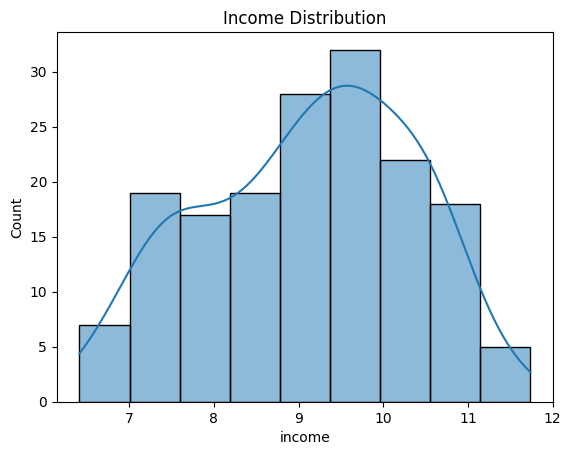

Skewness: -0.23582308003947594
count    167.000000
mean       9.115631
std        1.228722
min        6.413459
25%        8.118495
50%        9.206433
75%       10.034550
max       11.736077
Name: income, dtype: float64


In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['income'], kde=True)
plt.title("Income Distribution")
plt.show()

print("Skewness:", df['income'].skew())
print(df['income'].describe())

In [48]:
#Always combine:Statistical test ✔,Visual + skewness ✔

#Not just one.

In [49]:
#*income interpretation 
#Although the Shapiro-Wilk test indicates that the income variable is not perfectly normally distributed (p < 0.05), 
#the skewness value is close to zero and the mean and median are nearly equal. 
#***********This suggests the income distribution is approximately normal in practice, and no transformation is required.

In [50]:
#child_mort Distribution
from scipy.stats import shapiro

stat, p = shapiro(df['child_mort'])

print("W =", stat)
print("p-value =", p)
if p > 0.05:
    print("Data is normally distributed")
else:
    print("child_mort Data is NOT normally distributed")

W = 0.9564876039092342
p-value = 4.6529717153976566e-05
child_mort Data is NOT normally distributed


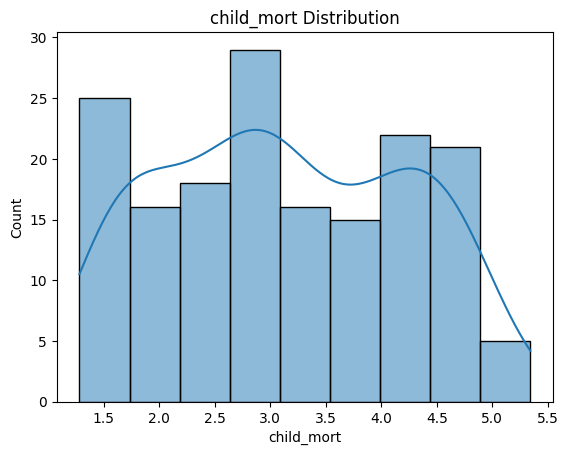

Skewness: 0.06615993685980348
count    167.000000
mean       3.127734
std        1.087226
min        1.280934
25%        2.223907
50%        3.010621
75%        4.144720
max        5.342334
Name: child_mort, dtype: float64


In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['child_mort'], kde=True)
plt.title("child_mort Distribution")
plt.show()

print("Skewness:", df['child_mort'].skew())
print(df['child_mort'].describe())

In [52]:
#in real-world EDA:

#Small dataset (<50) → trust Shapiro more
#Medium/Large dataset (like yours) →
#✔ Trust skewness + visualization more

#*****child_mort interpretation

#Although the Shapiro-Wilk test indicates that child mortality is not perfectly normally distributed (p < 0.05), 
#the skewness (0.066) is very close to zero and the mean and median are nearly equal. 
#T************his suggests that the child_mort distribution is approximately symmetric and can be treated as normal for practical analysis.

W = 0.926399834720548
p-value = 1.643108560820329e-07
life_expectancy  Data is NOT normally distributed


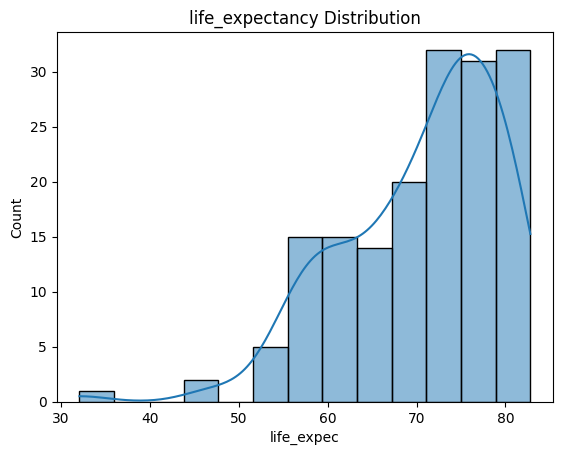

Skewness: -0.9709955819991258
count    167.000000
mean      70.555689
std        8.893172
min       32.100000
25%       65.300000
50%       73.100000
75%       76.800000
max       82.800000
Name: life_expec, dtype: float64


In [53]:
#Distribution of life expectancy
stat, p = shapiro(df['life_expec'])

print("W =", stat)
print("p-value =", p)
if p > 0.05:
    print("life_expectancy  Data is normally distributed")
else:
    print("life_expectancy  Data is NOT normally distributed")
sns.histplot(df['life_expec'], kde=True)
plt.title("life_expectancy Distribution")
plt.show()

print("Skewness:", df['life_expec'].skew())
print(df['life_expec'].describe())

In [54]:
#life_expectancy interpretation
#Most countries → high life expectancy (65–80)
#Few countries → very low life expectancy (30–50)

#*********👉 These low-value countries create the left tail

#The life expectancy distribution is negatively skewed (skewness ≈ -0.97), 
#indicating that most countries have relatively high life expectancy, while a few countries have significantly lower values. 
#The Shapiro-Wilk test (p < 0.05) confirms that the data is not normally distributed. 
#The presence of a long left tail suggests noticeable asymmetry in the distribution.

W = 0.972640744058203
p-value = 0.002184381256451799
gdpp Data is NOT normally distributed


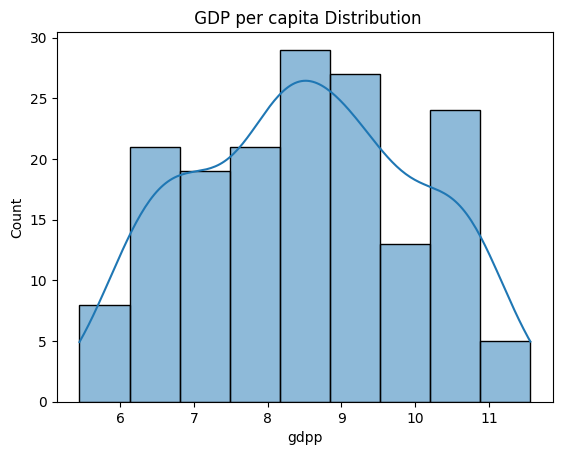

Skewness: 0.006548003622863535
count    167.000000
mean       8.500171
std        1.499398
min        5.446737
25%        7.193573
50%        8.446985
75%        9.549682
max       11.561725
Name: gdpp, dtype: float64


In [55]:
#GDP per capita spread
stat, p = shapiro(df['gdpp'])

print("W =", stat)
print("p-value =", p)
if p > 0.05:
    print("gdpp Data is normally distributed")
else:
    print("gdpp Data is NOT normally distributed")
sns.histplot(df['gdpp'], kde=True)
plt.title(" GDP per capita Distribution")
plt.show()

print("Skewness:", df['gdpp'].skew())
print(df['gdpp'].describe())

In [56]:
#gdpp interpretation
#Although the Shapiro-Wilk test indicates that gdpp is not perfectly normally distributed (p < 0.05), 
#the skewness is approximately zero (0.0065), and the mean and median are very close. 
#**********This suggests that the distribution is effectively symmetric and approximately normal in practice. No further transformation is required

W = 0.872212194198468
p-value = 9.826096669260985e-11
fertility rate Data is NOT normally distributed


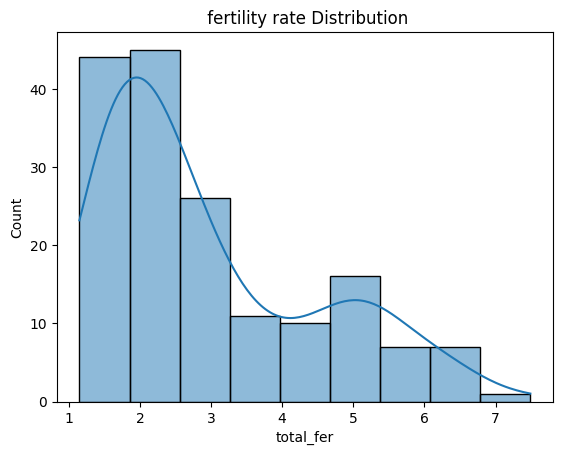

Skewness: 0.9670916808050207
count    167.000000
mean       2.947964
std        1.513848
min        1.150000
25%        1.795000
50%        2.410000
75%        3.880000
max        7.490000
Name: total_fer, dtype: float64


In [57]:
#Fertility rate analysis
stat, p = shapiro(df['total_fer'])

print("W =", stat)
print("p-value =", p)
if p > 0.05:
    print("fertility rate Data is normally distributed")
else:
    print("fertility rate Data is NOT normally distributed")
    
sns.histplot(df['total_fer'], kde=True)
plt.title(" fertility rate Distribution")
plt.show()

print("Skewness:", df['total_fer'].skew())
print(df['total_fer'].describe())

In [58]:
#fertility rate interpretation

#Mean (2.94) > Median (2.41) ✔
#Max (7.49) far from Q3 (3.88) ✔
#Shapiro test strongly rejects normality ✔

#👉So in practice:This is noticeably skewed, not “perfectly fine”
#Most countries → low fertility (1–3),Few countries → very high fertility (5–7+)

#*********👉 This creates a long right tail

#the fertility rate distribution is highly positively skewed (skewness = 0.97), with most countries having low to moderate fertility rates
#and a few countries exhibiting very high values. 
#The Shapiro-Wilk test (p < 0.05) strongly confirms that the data is not normally distributed. 
#The presence of a long right tail and potential outliers suggests that transformation or scaling may be required for further analysis.


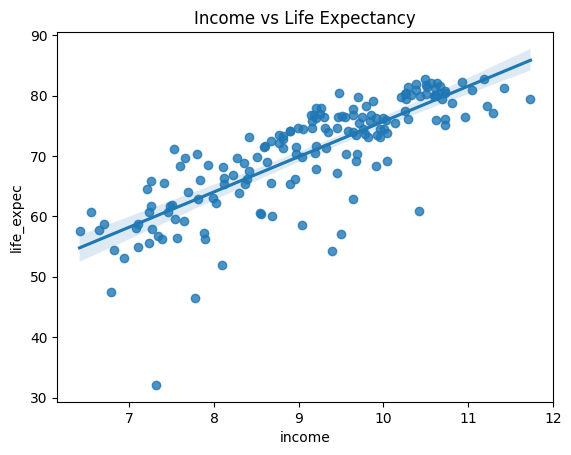

              income  life_expec
income      1.000000    0.805912
life_expec  0.805912    1.000000


In [59]:
#Income vs Life Expectancy
import seaborn as sns
import matplotlib.pyplot as plt

# Scatter + regression line
sns.regplot(x='income', y='life_expec', data=df)
plt.title("Income vs Life Expectancy")
plt.show()

# Correlation
corr = df[['income','life_expec']].corr()
print(corr)

In [60]:
#Income vs Life Expectancy interpretation
#There is a strong positive correlation (0.81) between income and life expectancy, 
#indicating that countries with higher income tend to have significantly better health outcomes. 
#This is likely due to improved healthcare access, nutrition, and overall living conditions, 
#although other socio-economic factors also play a role.

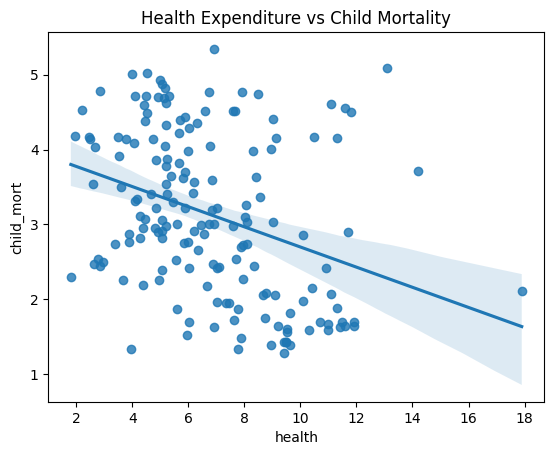

              health  child_mort
health      1.000000   -0.339588
child_mort -0.339588    1.000000


In [61]:
#Health Expenditure vs Child Mortality
sns.regplot(x='health', y='child_mort', data=df)
plt.title("Health Expenditure vs Child Mortality")
plt.show()

corr = df[['health','child_mort']].corr()
print(corr)

In [62]:
#Health Expenditure vs Child Mortality interpretation
#If slope is downward → negative relationship,Correlation < -0.5 → strong impact

#👉 Typical conclusion:Higher health expenditure is associated with lower child mortality, indicating effective healthcare systems.

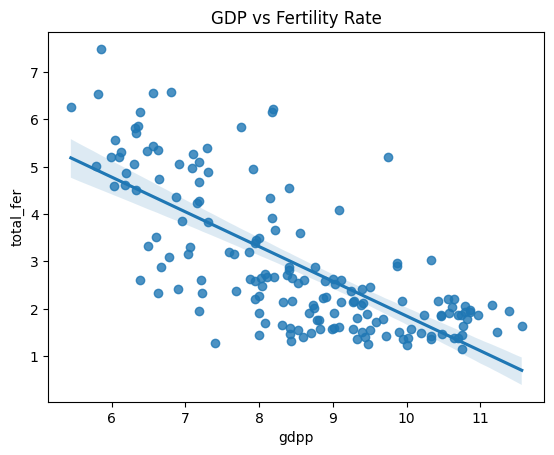

               gdpp  total_fer
gdpp       1.000000  -0.726786
total_fer -0.726786   1.000000


In [63]:
#GDP vs Fertility Rate
sns.regplot(x='gdpp', y='total_fer', data=df)
plt.title("GDP vs Fertility Rate")
plt.show()

corr = df[['gdpp','total_fer']].corr()
print(corr)

In [64]:
#GDP vs Fertility Rate interpretation
#Downward trend → richer countries have fewer children
#Correlation < -0.6 → strong inverse relation

#👉 Typical conclusion:

#As GDP increases, fertility rate decreases due to urbanization, education, and lifestyle changes.

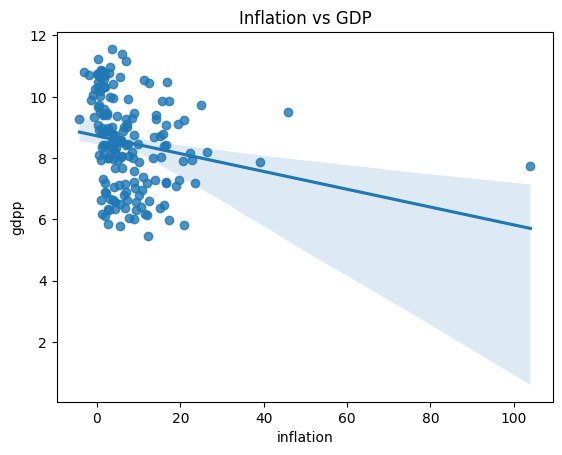

           inflation      gdpp
inflation   1.000000 -0.204728
gdpp       -0.204728  1.000000


In [65]:
#Inflation vs GDP
sns.regplot(x='inflation', y='gdpp', data=df)
plt.title("Inflation vs GDP")
plt.show()

corr = df[['inflation','gdpp']].corr()
print(corr)

In [66]:
#Inflation vs GDP interprtation
#If scattered → weak relationship
#Slight downward → inflation harms growth

#👉 Typical conclusion:
#Inflation does not show a strong direct relationship with GDP, but extremely high inflation is often seen in weaker economies.

In [67]:
df


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,inflation_log,development_index,trade_balance,health_impact_ratio,segment
0,Afghanistan,4.513055,10.0,7.58,44.9,7.384610,9.44,56.2,5.82,6.317165,2.750471,1.005442,-34.9,1.679572,low gdp trap
1,Albania,2.867899,28.0,6.55,48.6,9.203416,4.49,76.3,1.65,8.316545,2.370244,4.773639,-20.6,2.283902,low gdp trap
2,Algeria,3.342862,38.4,4.17,31.4,9.465060,16.10,76.5,2.89,8.403128,3.105035,3.806523,7.0,1.247434,high inflation risk
3,Angola,4.787492,62.3,2.85,42.9,8.682877,22.40,60.1,6.16,8.169336,3.353756,1.649172,19.4,0.595301,high inflation risk
4,Antigua and Barbuda,2.424803,45.5,6.03,58.9,9.857496,1.44,76.8,2.13,9.409273,2.034706,7.728587,-13.4,2.486800,low gdp trap
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,3.407842,46.6,5.25,52.7,7.989899,2.62,63.0,3.50,7.996654,2.178155,2.525619,-6.1,1.540564,low gdp trap
163,Venezuela,2.895912,28.5,4.91,17.6,9.711176,45.90,75.4,2.47,9.510519,3.953357,5.377130,10.9,1.695494,high inflation risk
164,Vietnam,3.190476,72.0,6.84,80.2,8.409831,12.10,73.1,1.95,7.178545,2.907447,3.120064,-8.2,2.143880,low gdp trap
165,Yemen,4.048301,30.0,5.18,34.4,8.407602,23.60,67.5,4.67,7.178545,3.394844,1.990196,-4.4,1.279549,high inflation risk


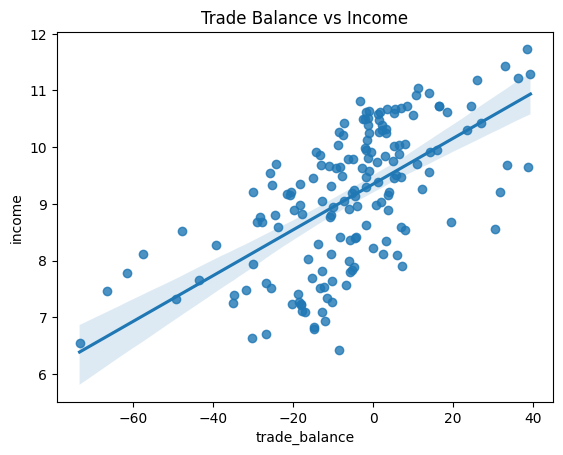

               trade_balance    income
trade_balance       1.000000  0.621655
income              0.621655  1.000000


In [68]:
#Trade Balance vs Income
sns.regplot(x='trade_balance', y='income', data=df)
plt.title("Trade Balance vs Income")
plt.show()

corr = df[['trade_balance','income']].corr()
print(corr)

In [69]:
#Mixed / weak trend is normal
#Slight positive → export-driven growth

#👉 Typical conclusion:

#Trade balance alone is not a strong predictor of income, though export-oriented countries may show higher income levels.

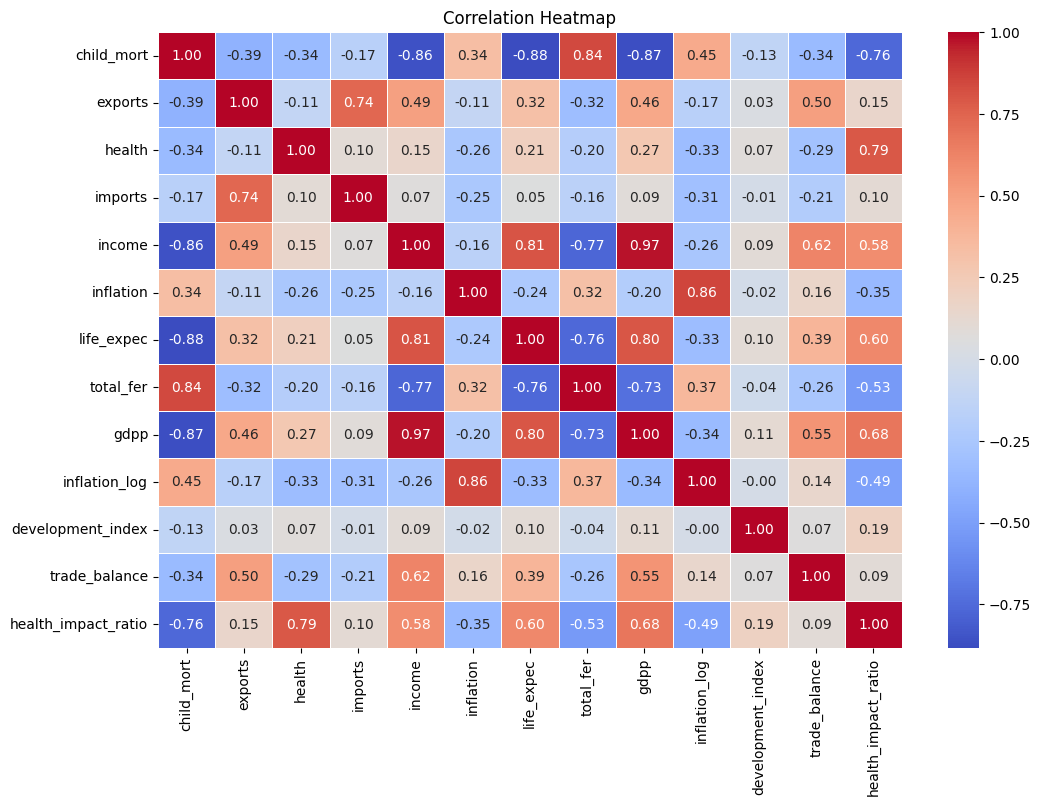

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,          # show values
    fmt=".2f",
    cmap="coolwarm",     # red-blue color
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [71]:
#“Life expectancy is mainly driven by economic strength and healthcare effectiveness, while child mortality and high fertility act as major negative factors.”

In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   country              167 non-null    str    
 1   child_mort           167 non-null    float64
 2   exports              167 non-null    float64
 3   health               167 non-null    float64
 4   imports              167 non-null    float64
 5   income               167 non-null    float64
 6   inflation            167 non-null    float64
 7   life_expec           167 non-null    float64
 8   total_fer            167 non-null    float64
 9   gdpp                 167 non-null    float64
 10  inflation_log        167 non-null    float64
 11  development_index    167 non-null    float64
 12  trade_balance        167 non-null    float64
 13  health_impact_ratio  167 non-null    float64
 14  segment              167 non-null    str    
dtypes: float64(13), str(2)
memory usage: 23.2 KB


In [73]:
# Correlation with life expectancy
life_corr = df.corr(numeric_only=True)['life_expec'].sort_values(ascending=False)
print("Top predictors of Life Expectancy:\n", life_corr)

# Correlation with child mortality
mort_corr = df.corr(numeric_only=True)['child_mort'].sort_values(ascending=False)
print("\nTop predictors of Child Mortality:\n", mort_corr)

Top predictors of Life Expectancy:
 life_expec             1.000000
income                 0.805912
gdpp                   0.797811
health_impact_ratio    0.604239
trade_balance          0.388226
exports                0.316313
health                 0.210692
development_index      0.100236
imports                0.054391
inflation             -0.239705
inflation_log         -0.330782
total_fer             -0.760875
child_mort            -0.883332
Name: life_expec, dtype: float64

Top predictors of Child Mortality:
 child_mort             1.000000
total_fer              0.839757
inflation_log          0.446702
inflation              0.336669
development_index     -0.132306
imports               -0.174058
health                -0.339588
trade_balance         -0.343662
exports               -0.391205
health_impact_ratio   -0.762359
income                -0.859310
gdpp                  -0.874668
life_expec            -0.883332
Name: child_mort, dtype: float64


In [74]:
df.to_csv("country_stats1.csv", index=False)

print("File converted to CSV successfully!")


File converted to CSV successfully!
